<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/Erreichbarkeiten_Auswertung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

statistische Auswertung der erreichbaren Flächen jeder Stadt
- wieviel % des Gesamtstadtgebiets sind innerhlab von x Minuten zu erreichen

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Isochrone-Shapefiles als GDFs laden

In [ ]:
isochrone_path = "/content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved"

In [ ]:
import geopandas as gpd
import os

# Get a list of all files in the directory
file_list = os.listdir(isochrone_path)

# Filter for shapefiles (files ending with .shp)
shapefile_list = [f for f in file_list if f.endswith('.shp')]

# Load each shapefile into a GeoDataFrame and store them in a dictionary
geodataframes = {}
for shapefile in shapefile_list:
    file_path = os.path.join(isochrone_path, shapefile)
    gdf = gpd.read_file(file_path)
    geodataframes[shapefile] = gdf

# Display the names of the loaded shapefiles and the first few rows of the first GeoDataFrame
print("Loaded shapefiles:")
for name in geodataframes.keys():
    print(name)

if geodataframes:
    first_gdf_name = list(geodataframes.keys())[0]
    print(f"\nFirst few rows of {first_gdf_name}:")
    display(geodataframes[first_gdf_name])

Loaded shapefiles:
Aschaffenburg_dissolved_accessibility_polygons.shp
Augsburg_dissolved_accessibility_polygons.shp
Bayreuth_dissolved_accessibility_polygons.shp
Erlangen_dissolved_accessibility_polygons.shp
Fürth_dissolved_accessibility_polygons.shp
Ingolstadt_dissolved_accessibility_polygons.shp
Landshut_dissolved_accessibility_polygons.shp
Passau_dissolved_accessibility_polygons.shp
Regensburg_dissolved_accessibility_polygons.shp
Rosenheim_dissolved_accessibility_polygons.shp
Schweinfurt_dissolved_accessibility_polygons.shp
Würzburg_dissolved_accessibility_polygons.shp

First few rows of Aschaffenburg_dissolved_accessibility_polygons.shp:


,travel_tim,geometry
0,5,"MULTIPOLYGON (((511888.569 5536500.187, 511880..."
1,10,"MULTIPOLYGON (((511596.711 5536840.785, 511705..."
2,15,"MULTIPOLYGON (((511429.253 5536777.217, 511454..."
3,20,"MULTIPOLYGON (((511184.507 5536830.359, 511284..."
4,25,"MULTIPOLYGON (((510823.876 5536088.44, 510901...."


# Wegegraphen (OSMnx) laden

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import os

# Directory where the graphml files are saved
output_dir = "/content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen"

# List to store the loaded graphs
graphs = {}

# Load the street networks from the graphml files
for filename in os.listdir(output_dir):
    if filename.endswith("_walk.graphml"):
        city_name = filename.replace("_walk.graphml", "").replace("_", " ")
        filepath = os.path.join(output_dir, filename)
        print(f"Loading street network for {city_name} from {filepath}...")
        try:
            G = ox.load_graphml(filepath)
            graphs[city_name] = G
            print(f"Loaded street network for {city_name}")
        except Exception as e:
            print(f"Could not load street network for {city_name}: {e}")

print("Finished loading street networks.")

Loading street network for Aschaffenburg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Aschaffenburg_walk.graphml...
Loaded street network for Aschaffenburg
Loading street network for Augsburg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Augsburg_walk.graphml...
Loaded street network for Augsburg
Loading street network for Bamberg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Bamberg_walk.graphml...
Loaded street network for Bamberg
Loading street network for Bayreuth from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Bayreuth_walk.graphml...
Loaded street network for Bayreuth
Loading street network for Erlangen from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Erlangen_walk.graphml...
Loaded street network for Erlangen
Loading street network for Fürth from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Fürth_walk.graphml...
Loaded street network for Fürth
Loading street network for Ingolst

# Cold Spots laden (2019-2024)

In [ ]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
input_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the input folders for the different significance levels for the 2019-2024 period
input_folder_p005_2019_2024 = os.path.join(input_base_dir, "cold_spots_p005")
input_folder_p010_2019_2024 = os.path.join(input_base_dir, "cold_spots_p010")

# Initialize dictionaries to store the loaded Cold Spot geodataframes for 2019-2024
loaded_cold_spots_p005_2019_2024 = {}
loaded_cold_spots_p010_2019_2024 = {}

print(f"Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: {input_folder_p005_2019_2024}")

# Load Cold Spots with p<0.05 for 2019-2024
if os.path.exists(input_folder_p005_2019_2024):
    for filename in os.listdir(input_folder_p005_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p005_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_", " ")
                # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p005_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_folder_p005_2019_2024}")


print(f"\nLade Cold Spots (p<0.10) für 2019-2024 aus dem Ordner: {input_folder_p010_2019_2024}")

# Load Cold Spots with p<0.10 for 2019-2024
if os.path.exists(input_folder_p010_2019_2024):
    for filename in os.listdir(input_folder_p010_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p010_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_", " ")
                 # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p010_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
     print(f"  Ordner nicht gefunden: {input_folder_p010_2019_2024}")


print("\nLaden der Cold Spot Ergebnisse für 2019-2024 abgeschlossen.")

# You can now access the loaded cold spot geodataframes using the dictionaries
# For example: munich_cold_spots_p005_2019_2024 = loaded_cold_spots_p005_2019_2024['Munich']

Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_p005
  Geladen: Augsburg_cold_spots_p005.geojson (Augsburg cold spots p005.geojson)
  Geladen: Erlangen_cold_spots_p005.geojson (Erlangen cold spots p005.geojson)
  Geladen: Bayreuth_cold_spots_p005.geojson (Bayreuth cold spots p005.geojson)
  Geladen: Landshut_cold_spots_p005.geojson (Landshut cold spots p005.geojson)
  Geladen: Ingolstadt_cold_spots_p005.geojson (Ingolstadt cold spots p005.geojson)
  Geladen: Passau_cold_spots_p005.geojson (Passau cold spots p005.geojson)
  Geladen: Rosenheim_cold_spots_p005.geojson (Rosenheim cold spots p005.geojson)
  Geladen: Schweinfurt_cold_spots_p005.geojson (Schweinfurt cold spots p005.geojson)
  Geladen: Regensburg_cold_spots_p005.geojson (Regensburg cold spots p005.geojson)
  Geladen: Nuremberg_cold_spots_p005.geojson (Nuremberg cold spots p005.geojson)
  Geladen: Würzburg_cold_spots_p005.geojson (Würzburg cold spots p005.geojson)
  G

# Erreichbarkeiten visualisieren


Visualizing accessibility polygons and cold spots for selected cities: ['Aschaffenburg', 'Augsburg', 'Bayreuth', 'Erlangen', 'Fürth', 'Ingolstadt', 'Landshut', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Würzburg']

Visualizing for city: Aschaffenburg
  Accessed street network graph for Aschaffenburg
  Projecting graph for Aschaffenburg to EPSG:32632 for plotting
  Finished projecting graph for Aschaffenburg


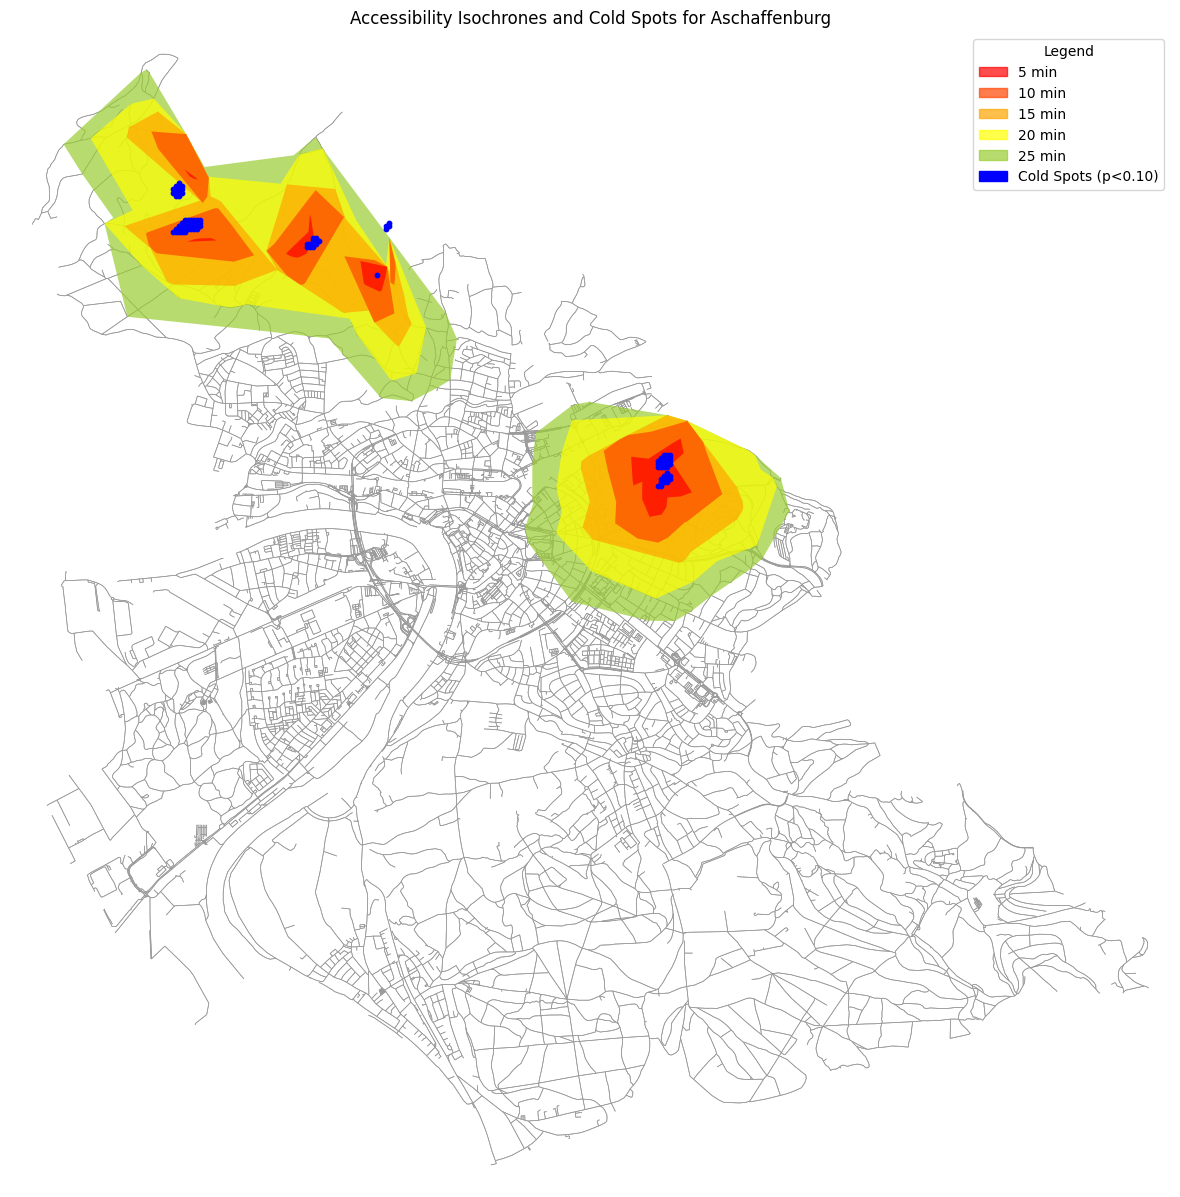


Visualizing for city: Augsburg
  Accessed street network graph for Augsburg
  Projecting graph for Augsburg to EPSG:32632 for plotting
  Finished projecting graph for Augsburg


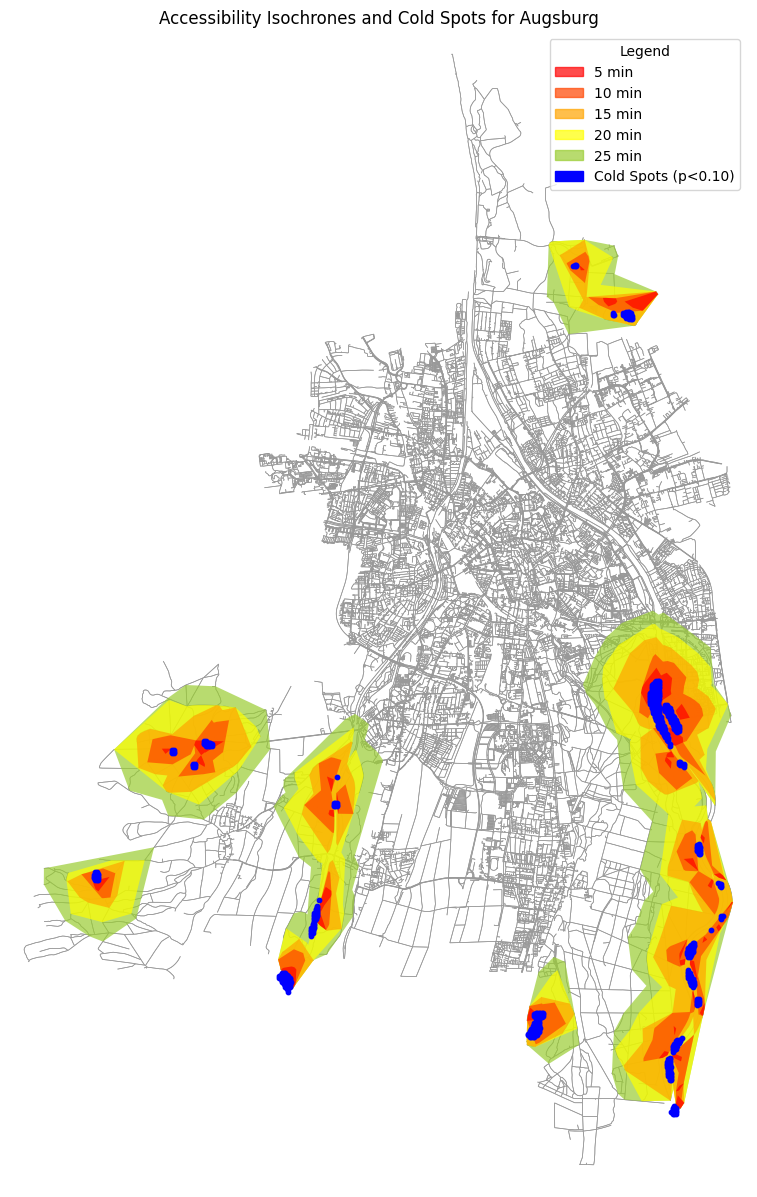


Visualizing for city: Bayreuth
  Accessed street network graph for Bayreuth
  Projecting graph for Bayreuth to EPSG:32632 for plotting
  Finished projecting graph for Bayreuth


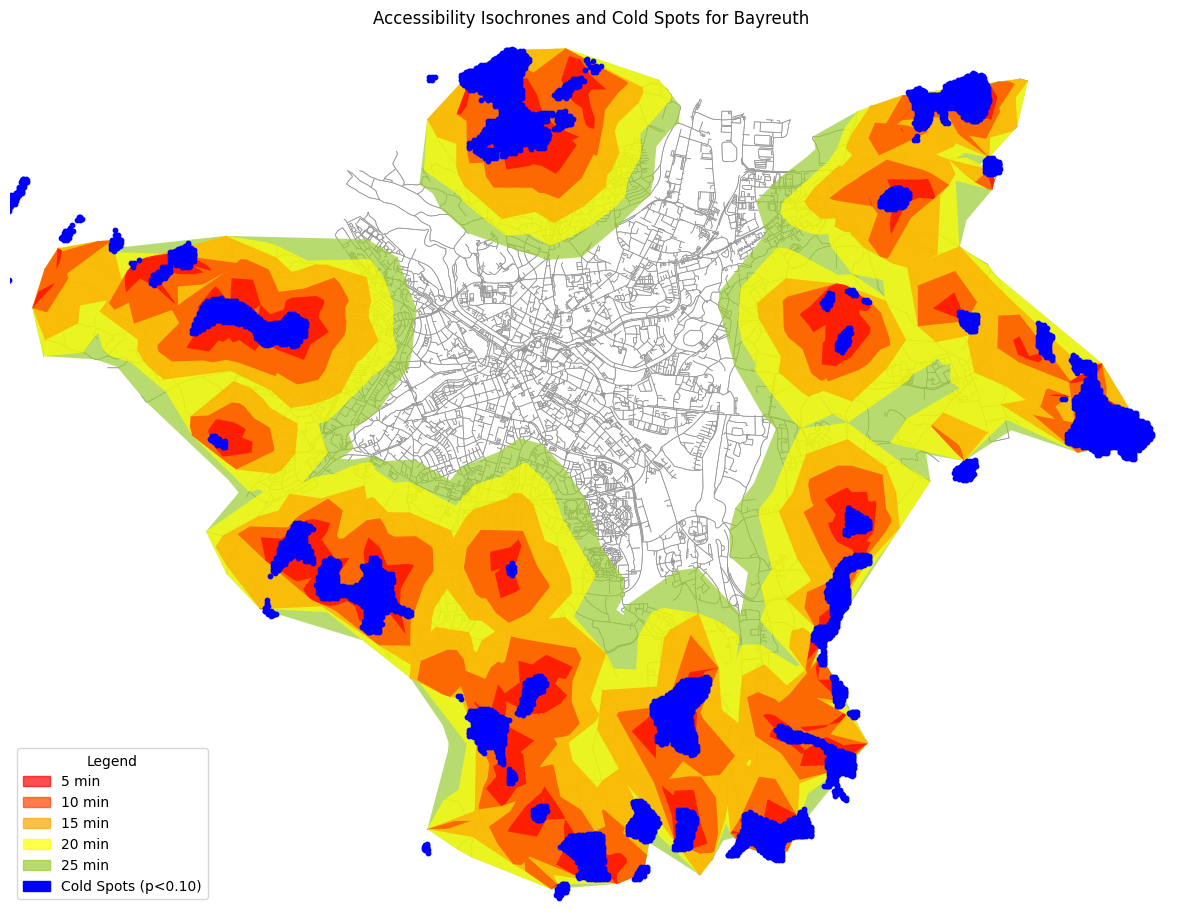


Visualizing for city: Erlangen
  Accessed street network graph for Erlangen
  Projecting graph for Erlangen to EPSG:32632 for plotting
  Finished projecting graph for Erlangen


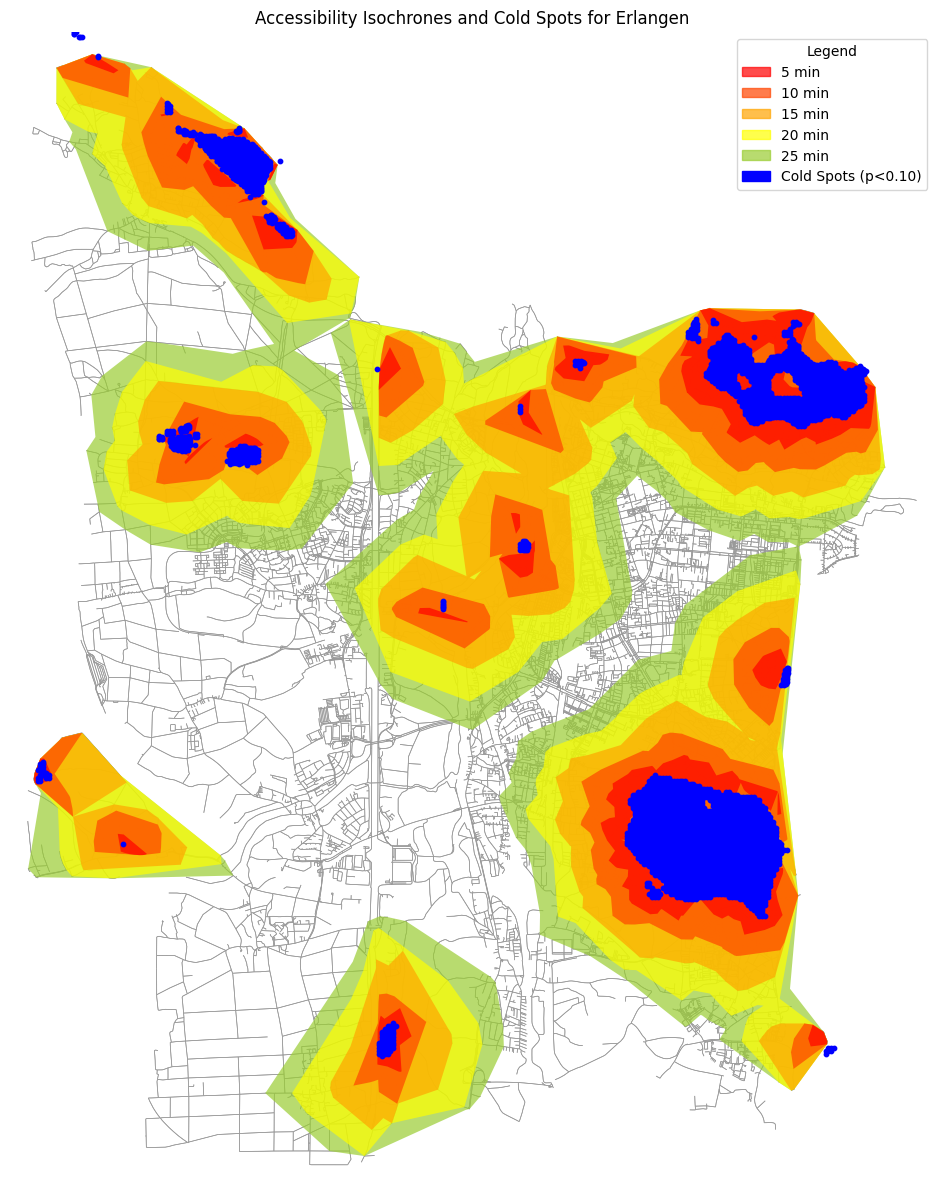


Visualizing for city: Fürth
  Accessed street network graph for Fürth
  Projecting graph for Fürth to EPSG:32632 for plotting
  Finished projecting graph for Fürth


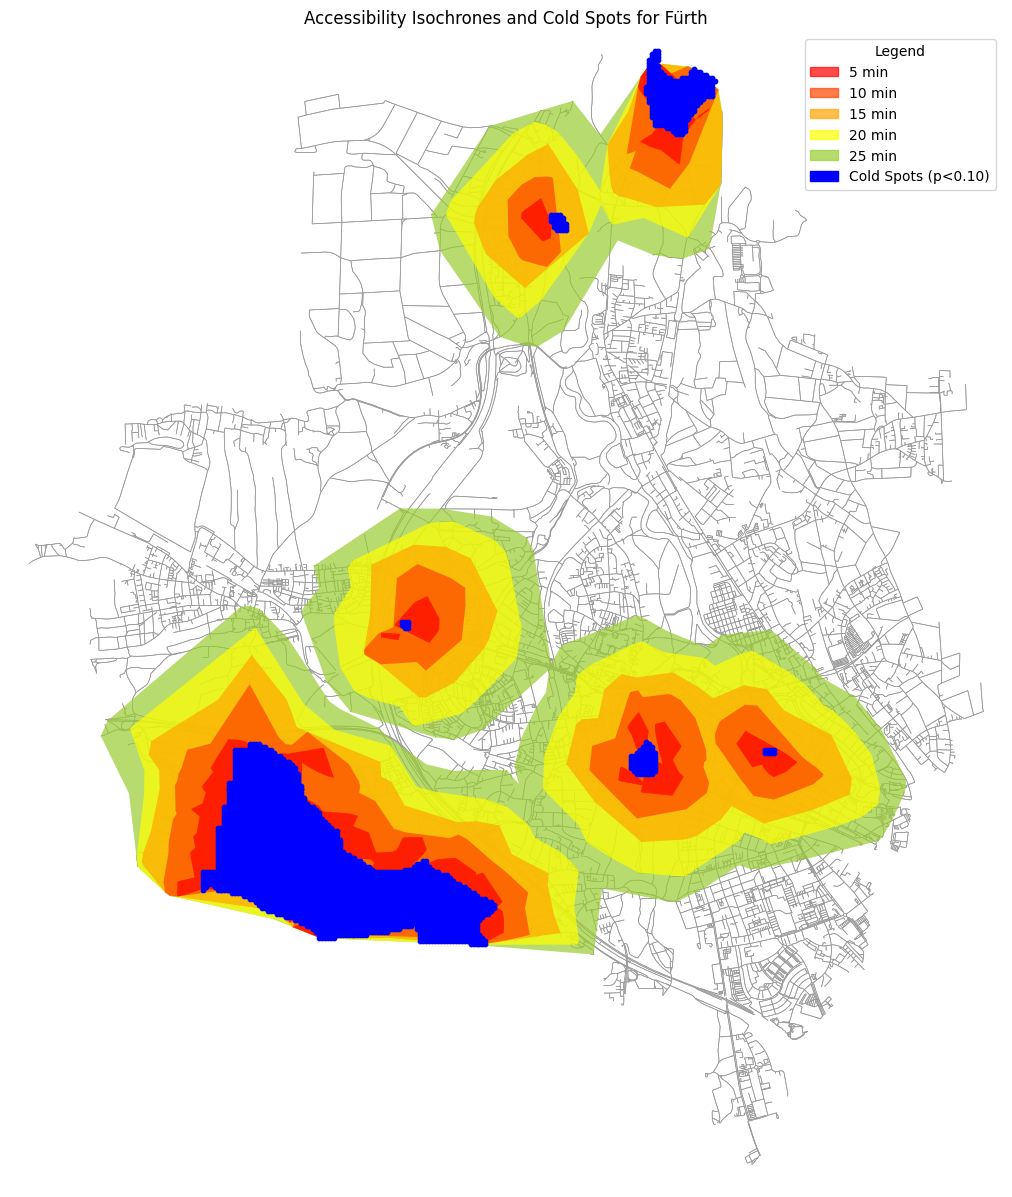


Visualizing for city: Ingolstadt
  Accessed street network graph for Ingolstadt
  Projecting graph for Ingolstadt to EPSG:32632 for plotting
  Finished projecting graph for Ingolstadt


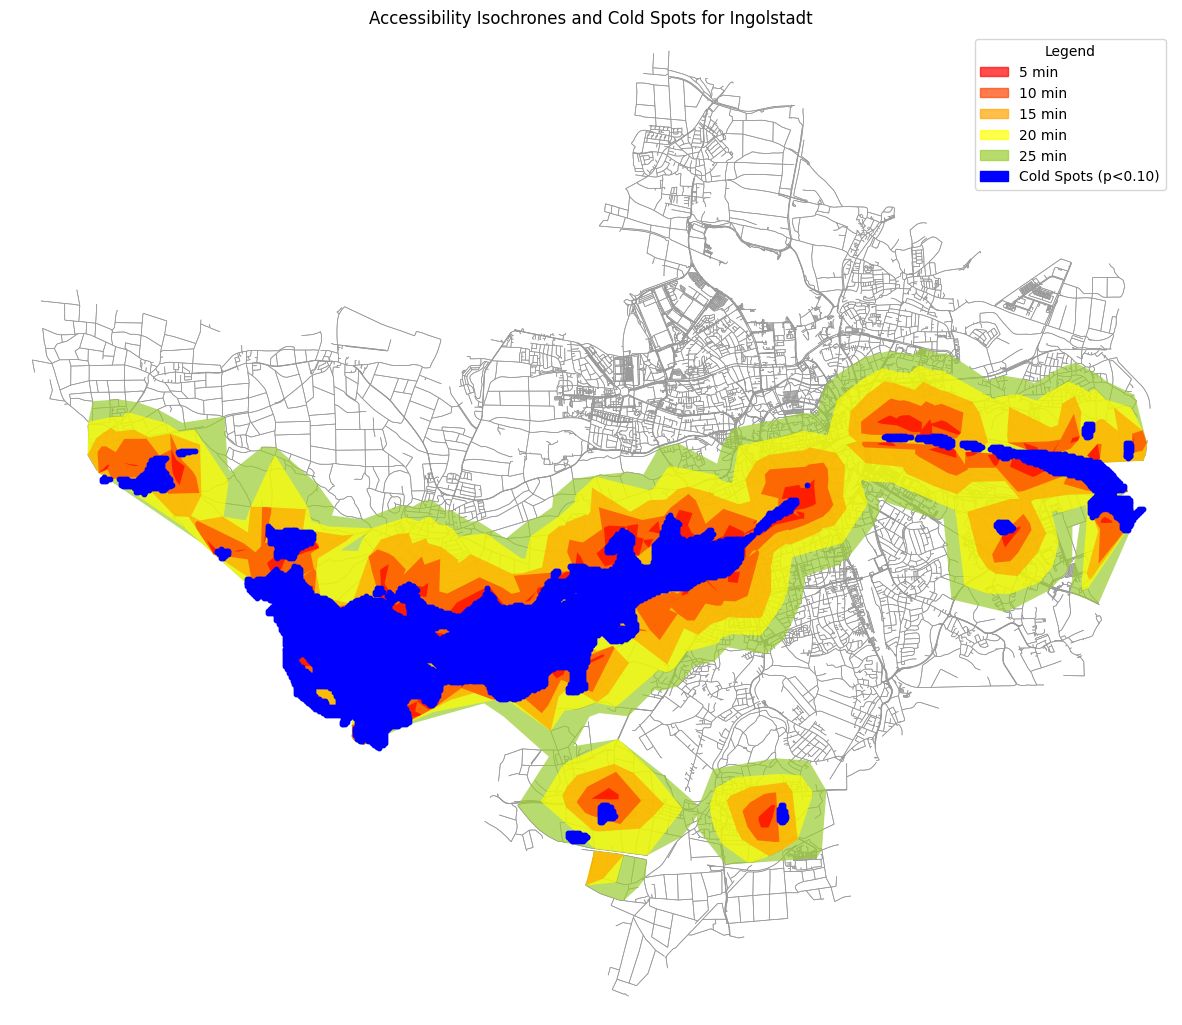


Visualizing for city: Landshut
  Accessed street network graph for Landshut
  Projecting graph for Landshut to EPSG:32632 for plotting
  Finished projecting graph for Landshut


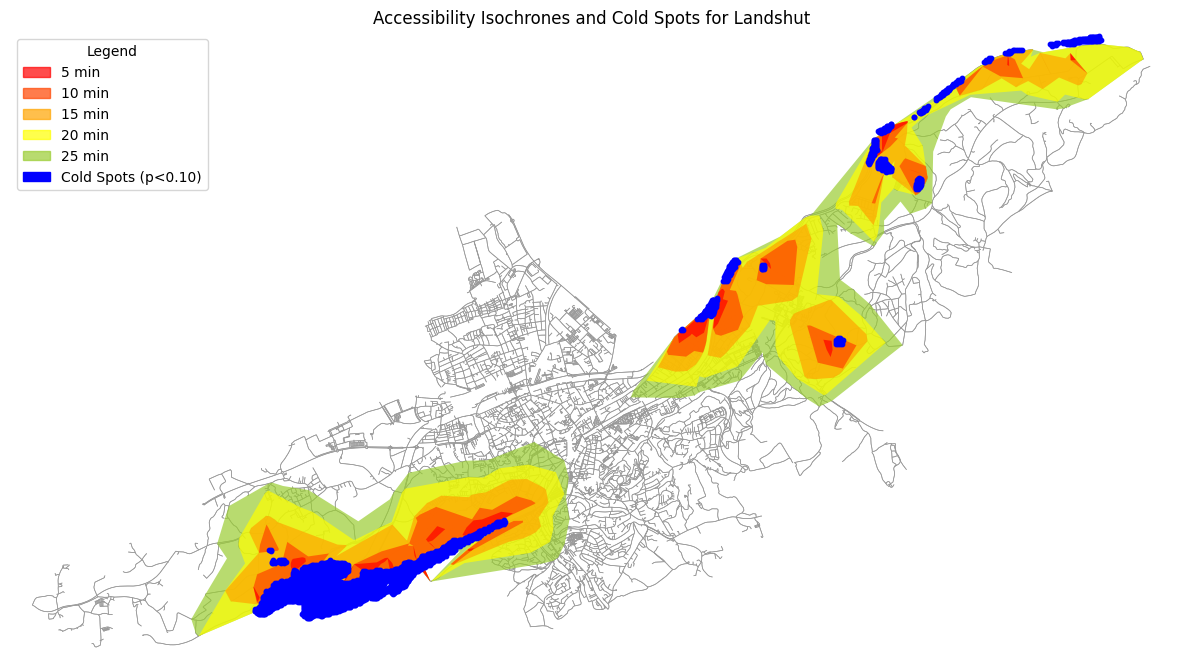


Visualizing for city: Passau
  Accessed street network graph for Passau
  Projecting graph for Passau to EPSG:32632 for plotting
  Finished projecting graph for Passau


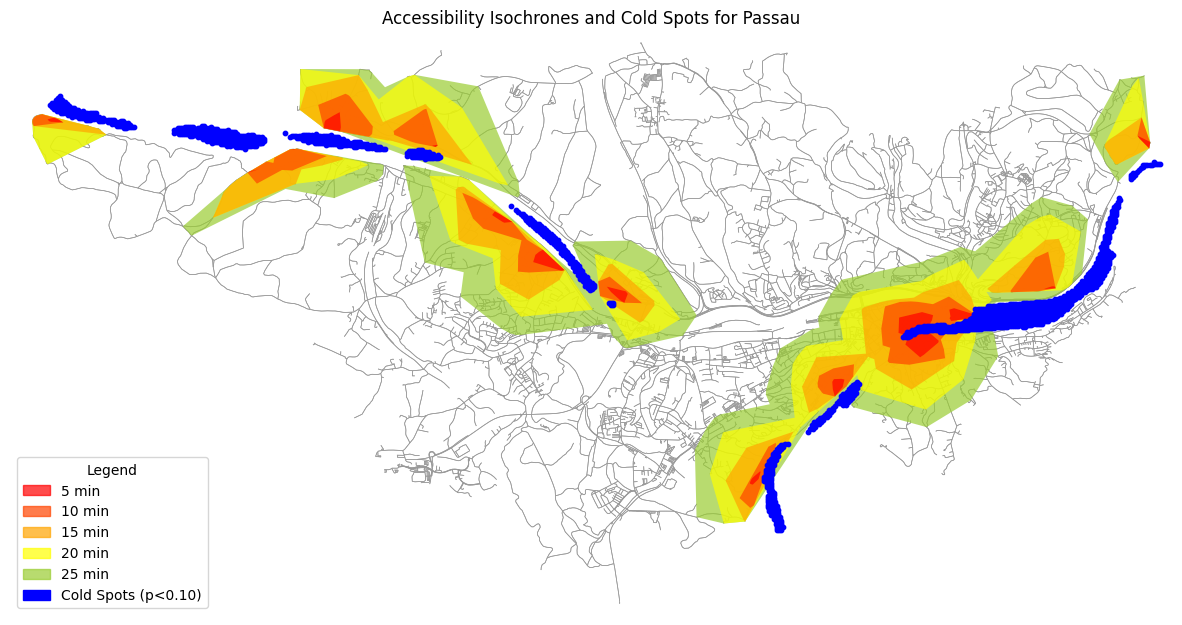


Visualizing for city: Regensburg
  Accessed street network graph for Regensburg
  Projecting graph for Regensburg to EPSG:32632 for plotting
  Finished projecting graph for Regensburg


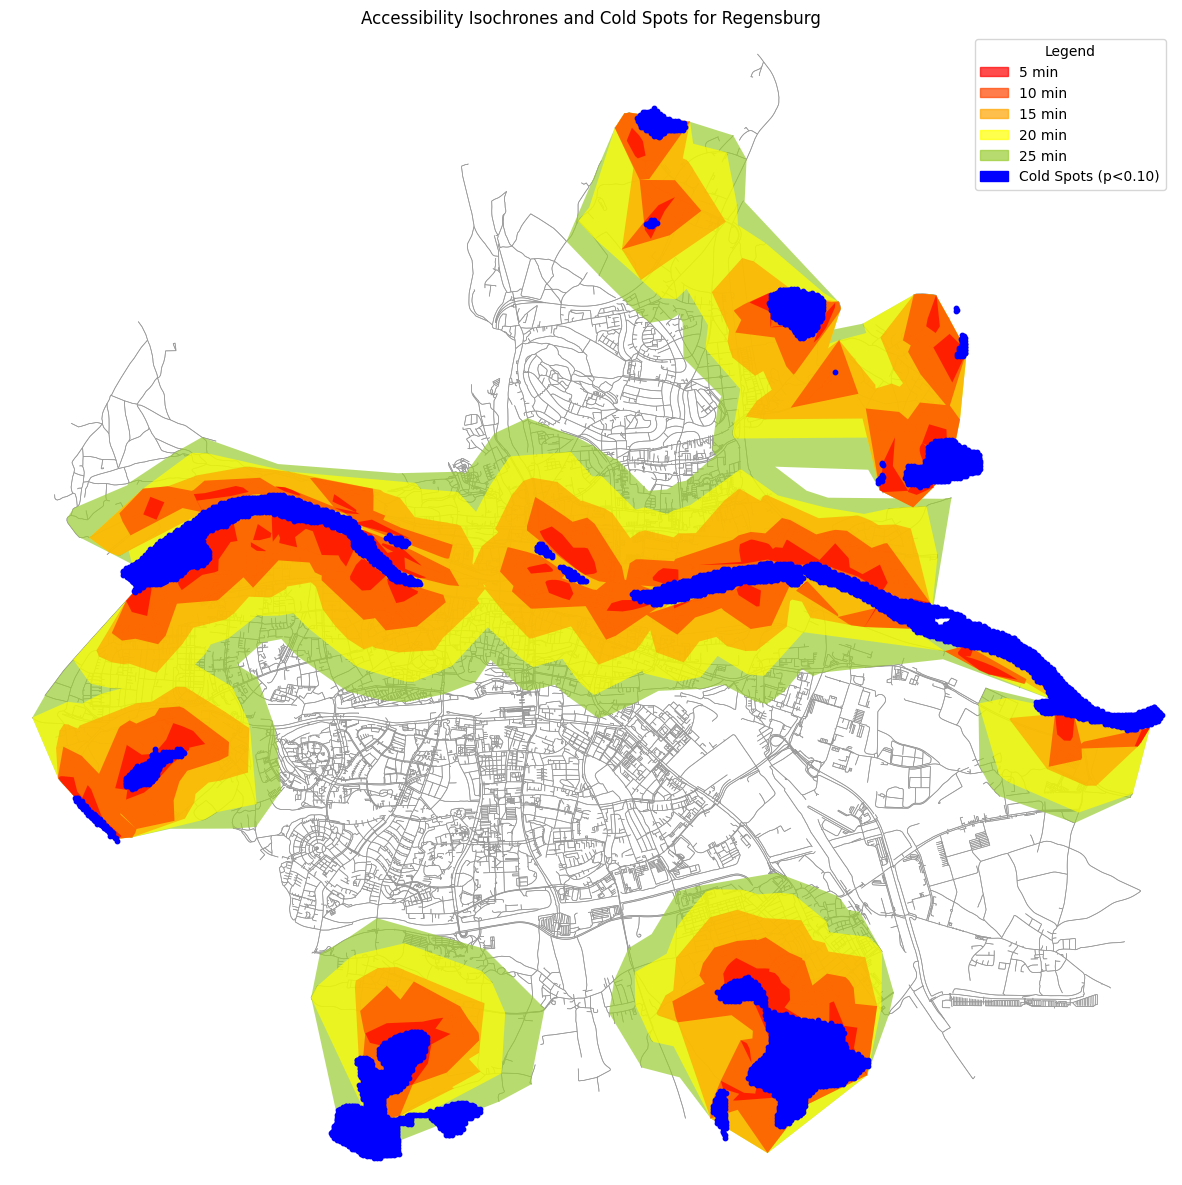


Visualizing for city: Rosenheim
  Accessed street network graph for Rosenheim
  Projecting graph for Rosenheim to EPSG:32632 for plotting
  Finished projecting graph for Rosenheim


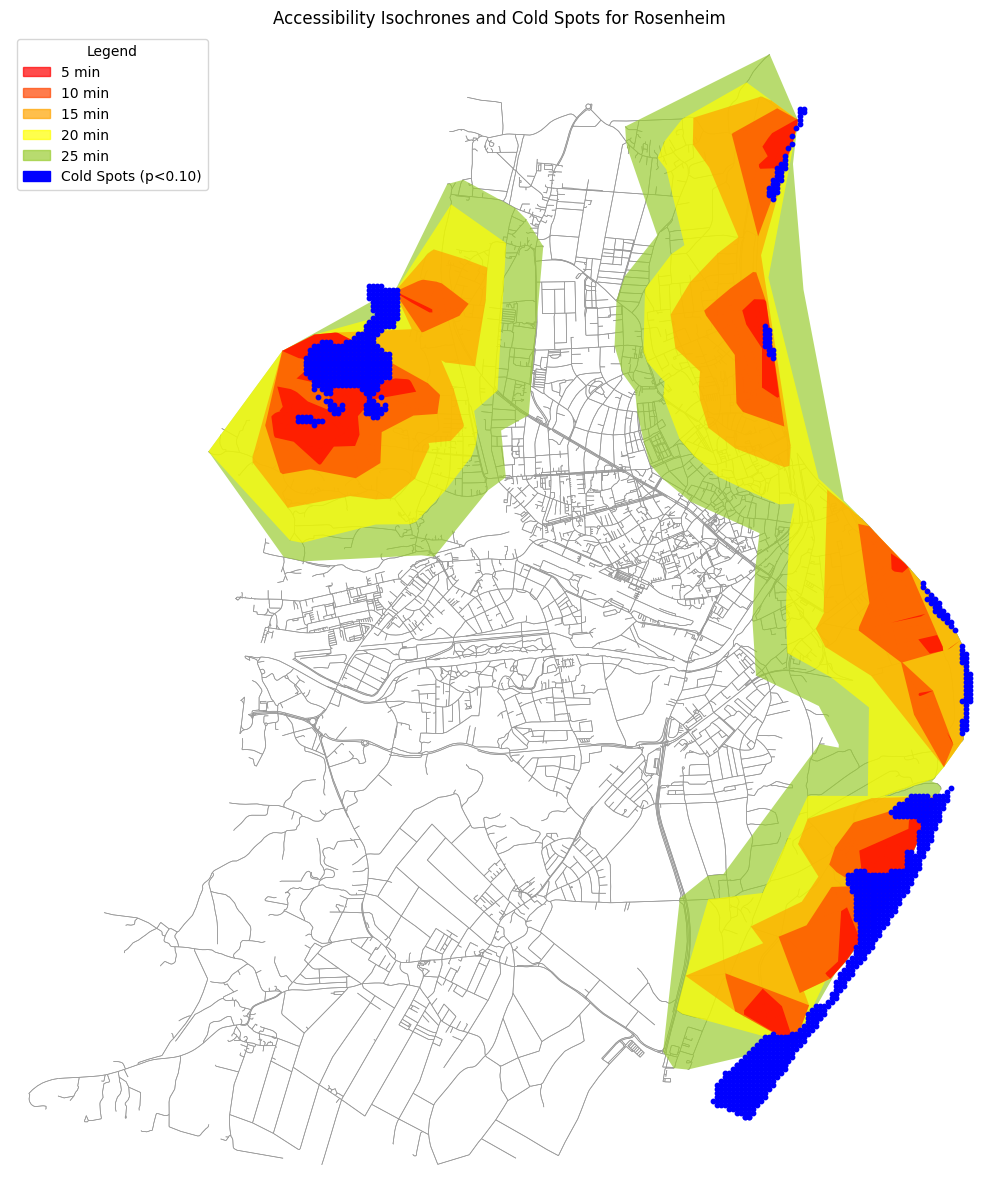


Visualizing for city: Schweinfurt
  Accessed street network graph for Schweinfurt
  Projecting graph for Schweinfurt to EPSG:32632 for plotting
  Finished projecting graph for Schweinfurt


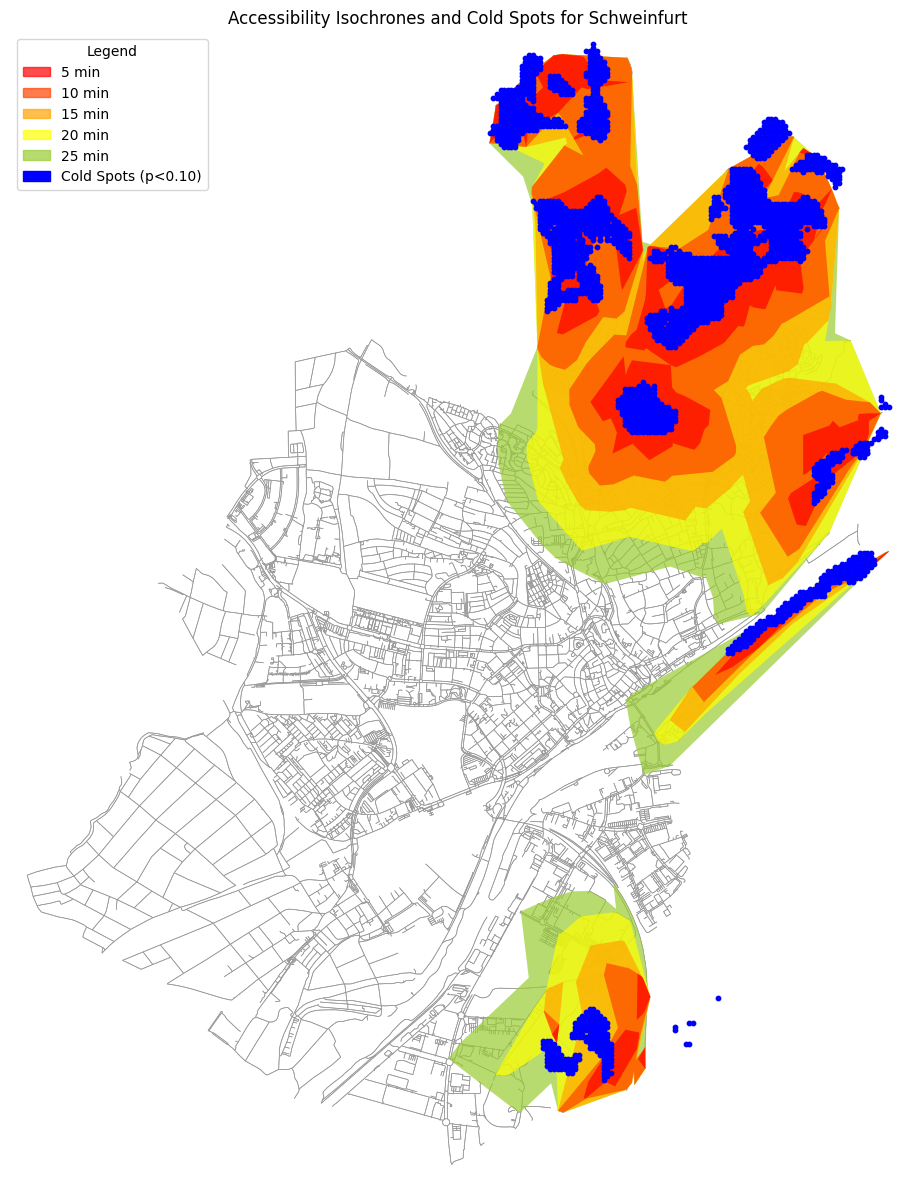


Visualizing for city: Würzburg
  Accessed street network graph for Würzburg
  Projecting graph for Würzburg to EPSG:32632 for plotting
  Finished projecting graph for Würzburg


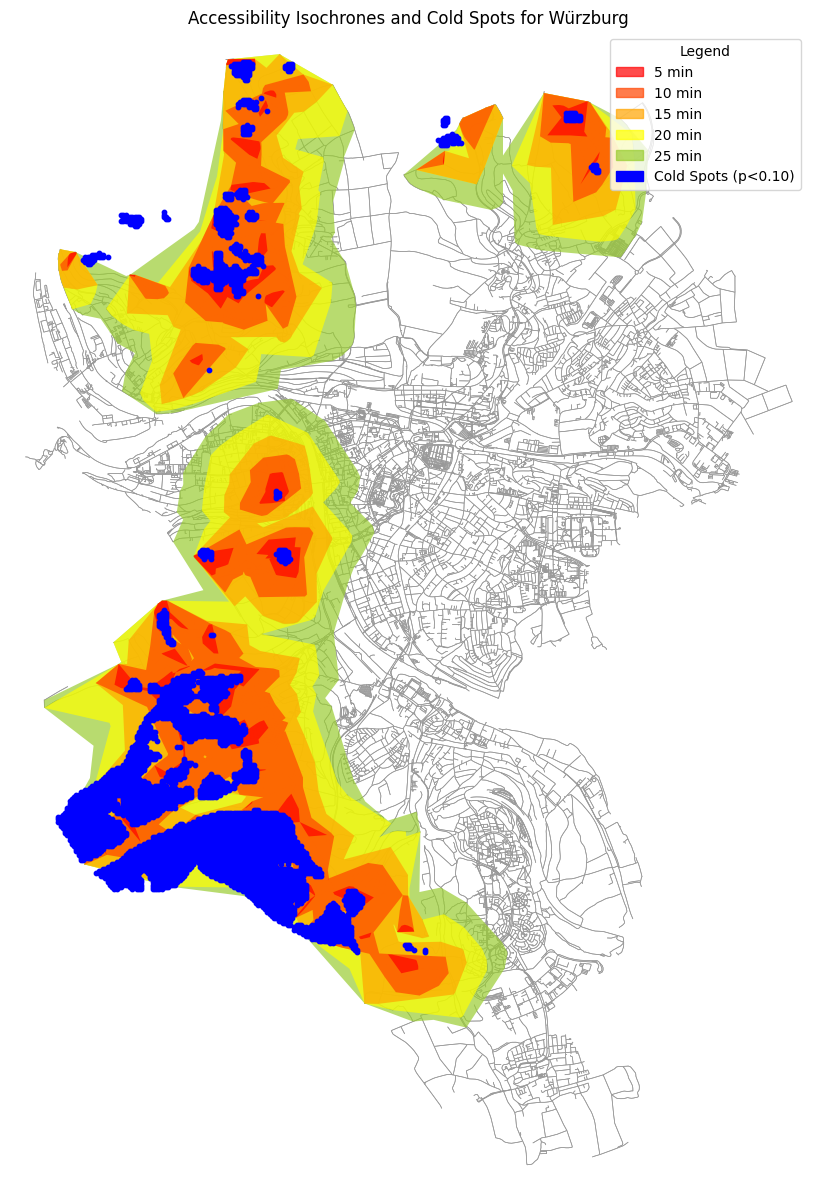

Finished generating maps.


In [ ]:
import matplotlib.pyplot as plt
import osmnx as ox
import geopandas as gpd
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection

# Assuming 'graphs' contains the street networks, 'geodataframes' contains the isochrones,
# and 'loaded_cold_spots_p010_2019_2024' contains the cold spots with p<0.10

# Define a list of cities to visualize (subset of processed cities)
# You can change this list
cities_to_visualize = ['Aschaffenburg', 'Augsburg', 'Bayreuth', 'Erlangen', 'Fürth', 'Ingolstadt', 'Landshut', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Würzburg']


print(f"\nVisualizing accessibility polygons and cold spots for selected cities: {cities_to_visualize}")

# Iterate through the selected cities for visualization
for city_name in cities_to_visualize:
    # Find the corresponding geodataframe for the city
    isochrone_gdf = None
    for gdf_name, gdf in geodataframes.items():
        # Match city name, accounting for potential underscores in filename
        if city_name.replace(" ", "_") in gdf_name:
            isochrone_gdf = gdf
            break

    # Find the corresponding cold spots geodataframe for the city (p<0.10)
    cold_spots_gdf = None
    # Iterate through the keys in loaded_cold_spots_p010_2019_2024
    for cold_spot_name, gdf in loaded_cold_spots_p010_2019_2024.items():
        # Extract city name from the key by removing the suffix and replacing underscores
        # Ensure consistent city name format with the graphs and isochrones
        extracted_city_name = cold_spot_name.replace("_cold_spots_p010.geojson", "").replace(" cold spots p010.geojson", "").replace("_", " ")
        extracted_city_name = extracted_city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        extracted_city_name = extracted_city_name.replace("Kempten Allgäu", "Kempten (Allgäu)") # Specific handling for Kempten

        if city_name == extracted_city_name:
            cold_spots_gdf = gdf
            break


    if isochrone_gdf is not None:
        print(f"\nVisualizing for city: {city_name}")

        # Access the street network graph for the current city
        if city_name in graphs:
            G = graphs[city_name]
            print(f"  Accessed street network graph for {city_name}")

            # Project the graph to the same CRS as the accessibility polygons
            if G.graph['crs'] != isochrone_gdf.crs:
                print(f"  Projecting graph for {city_name} to {isochrone_gdf.crs} for plotting")
                graph_proj = ox.project_graph(G, to_crs=isochrone_gdf.crs)
                print(f"  Finished projecting graph for {city_name}")
            else:
                graph_proj = G
                print(f"  Graph for {city_name} is already in {isochrone_gdf.crs}")

            # --- Plotting ---
            # Create a single figure and axes for the current city
            fig, ax = plt.subplots(figsize=(15, 15))

            # Plot the street network
            ox.plot_graph(graph_proj, ax=ax, node_size=0, edge_color='#999999', edge_linewidth=0.5, show=False, close=False) # Reduced linewidth

            # Define colors for each travel time (from 5 to 25 minutes)
            colors = ['#ff0000', '#ff4500', '#ffa500', '#ffff00', '#9acd32'] # Example colors (red to yellow-green)
            travel_times = [5, 10, 15, 20, 25]

            # Create proxy artists for the legend for isochrones
            legend_handles = []
            for i, time in enumerate(travel_times):
                 # Check if there's actually data for this travel time
                 if not isochrone_gdf[isochrone_gdf['travel_tim'] == time].empty:
                    patch = mpatches.Patch(color=colors[i], alpha=0.7, label=f'{time} min')
                    legend_handles.append(patch)


            # Plot each isochrone with a specific color and zorder
            # zorder is set to layer 5 min on top (highest zorder value)
            for i, time in enumerate(travel_times):
                isochrone = isochrone_gdf[isochrone_gdf['travel_tim'] == time]
                if not isochrone.empty:
                    # Use the same axis for plotting isochrones
                    isochrone.plot(ax=ax, color=colors[i], alpha=0.7, zorder=len(travel_times) - i)


            # Plot cold spots if available
            if cold_spots_gdf is not None and not cold_spots_gdf.empty:
                 # Ensure cold spots are in the same CRS as the isochrones for plotting
                if cold_spots_gdf.crs != isochrone_gdf.crs:
                    cold_spots_gdf = cold_spots_gdf.to_crs(isochrone_gdf.crs)
                cold_spots_gdf.plot(ax=ax, color='blue', markersize=10, label='Cold Spots (p<0.10)', zorder=len(travel_times) + 1) # Plot cold spots on top
                # Add cold spots to legend handles
                legend_handles.append(mpatches.Patch(color='blue', label='Cold Spots (p<0.10)'))


            # Add a legend
            if legend_handles:
                ax.legend(handles=legend_handles, title="Legend")


            # Set title
            ax.set_title(f"Accessibility Isochrones and Cold Spots for {city_name}")

            # Show the plot
            plt.show()
        else:
            print(f"  No street network graph found for {city_name}")
    else:
        print(f"No isochrone data found for {city_name}")

print("Finished generating maps.")

# Statistische Auswertungen

## Städte-Polygone laden

In [ ]:
# Define the path to the GeoPackage file
city_boundaries_path = "/content/drive/MyDrive/Cold Spots Bayern/grenzen_ueber_50tsd.gpkg"

# Load the GeoPackage file into a GeoDataFrame
city_boundaries_gdf = gpd.read_file(city_boundaries_path)

# Display the first few rows and the CRS of the GeoDataFrame
print("City Boundaries GeoDataFrame:")
display(city_boundaries_gdf.head())
print("\nCity Boundaries CRS:")
print(city_boundaries_gdf.crs)

City Boundaries GeoDataFrame:


,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,11.360777,48.061624,11.722910,48.248116,116687199,relation,62428,48.137108,11.575382,boundary,administrative,12,0.799006,city,Munich,"Munich, Bavaria, Germany","MULTIPOLYGON (((11.36078 48.15807, 11.36085 48..."
1,10.988733,49.331434,11.282596,49.540753,115962439,relation,62780,49.453872,11.077298,boundary,administrative,12,0.709195,city,Nuremberg,"Nuremberg, Bavaria, Germany","MULTIPOLYGON (((10.98873 49.53654, 10.98906 49..."
2,10.763362,48.258144,10.959333,48.458654,116219980,relation,62407,48.369034,10.897952,boundary,administrative,12,0.679385,city,Augsburg,"Augsburg, Bavaria, Germany","MULTIPOLYGON (((10.76336 48.30213, 10.76336 48..."
3,12.029075,48.966746,12.191608,49.076416,119951011,relation,62411,49.019533,12.097487,boundary,administrative,12,0.670191,city,Regensburg,"Regensburg, Bavaria, Germany","MULTIPOLYGON (((12.02907 49.01102, 12.02908 49..."
4,11.255908,48.683877,11.503422,48.822891,116627625,relation,62381,48.763016,11.425040,boundary,administrative,12,0.625744,city,Ingolstadt,"Ingolstadt, Bavaria, Germany","MULTIPOLYGON (((11.25591 48.77946, 11.25634 48..."



City Boundaries CRS:
EPSG:4326


## Gesamtfläche berechnen

**Reasoning**:
Reproject the city boundaries GeoDataFrame to a suitable projected CRS and calculate the area of each city polygon in square kilometers.



In [ ]:
# Reproject to a suitable projected CRS (e.g., ETRS89 / UTM zone 32N for parts of Bavaria)
# You might need to adjust the CRS based on the specific location of the cities
# A common projection for Germany is EPSG:25832 (ETRS89 / UTM zone 32N)
city_boundaries_gdf_proj = city_boundaries_gdf.to_crs(epsg=25832)

# Calculate the area of each polygon in square meters (unit of EPSG:25832)
city_boundaries_gdf_proj['area_sq_m'] = city_boundaries_gdf_proj.geometry.area

# Convert the area to square kilometers
city_boundaries_gdf_proj['area_sq_km'] = city_boundaries_gdf_proj['area_sq_m'] / 1_000_000

# Display the city names and their calculated areas in square kilometers
print("City Areas in Square Kilometers:")
display(city_boundaries_gdf_proj[['name', 'area_sq_km']])

City Areas in Square Kilometers:


,name,area_sq_km
0,Munich,310.737348
1,Nuremberg,186.704548
2,Augsburg,146.758964
3,Regensburg,80.671608
4,Ingolstadt,133.392428
5,Würzburg,87.613572
6,Fürth,63.335486
7,Erlangen,77.010016
8,Bamberg,54.571212
9,Bayreuth,66.901747


## Erreichbare Flächen berechnen


In [ ]:
# Dictionary to store the calculated areas of isochrones
isochrone_areas = {}

# Define the target CRS
target_crs = "EPSG:25832"

# Iterate through each city's GeoDataFrame in the geodataframes dictionary
for city_filename, isochrone_gdf in geodataframes.items():
    # Extract city name from filename
    city_name = city_filename.replace("_dissolved_accessibility_polygons.shp", "").replace("_", " ")
    # Handle umlaut for Fürth if necessary
    if 'Fürth' in city_name:
        city_name = city_name.replace('Fürth', 'Fürth')

    print(f"\nProcessing city: {city_name}")

    # Reproject the isochrone GeoDataFrame to the target CRS
    isochrone_gdf_proj = isochrone_gdf.to_crs(target_crs)
    print(f"  Reprojected to {target_crs}")

    # Initialize a dictionary for the current city's isochrone areas
    isochrone_areas[city_name] = {}

    # Define the travel times to process
    travel_times = [5, 10, 15, 20, 25]

    # For each travel time, filter and calculate the area
    for time in travel_times:
        # Filter the reprojected isochrone GeoDataFrame for the current travel time
        time_isochrone = isochrone_gdf_proj[isochrone_gdf_proj['travel_tim'] == time]

        # Calculate the area of the filtered isochrone polygon
        # If there is a geometry, calculate its area, otherwise the area is 0
        if not time_isochrone.empty:
            # Assuming the filtered result is a single multi-polygon row
            area_sq_m = time_isochrone.geometry.iloc[0].area
            print(f"    Calculated area for {time} min isochrone: {area_sq_m:.2f} sq m")
        else:
            area_sq_m = 0
            print(f"    No geometry found for {time} min isochrone, area is 0")


        # Store the calculated area
        isochrone_areas[city_name][time] = area_sq_m

# Print the dictionary with calculated areas for verification
print("\nCalculated Isochrone Areas (sq m):")
for city, areas in isochrone_areas.items():
    print(f"  {city}: {areas}")


Processing city: Aschaffenburg
  Reprojected to EPSG:25832
    Calculated area for 5 min isochrone: 341922.65 sq m
    Calculated area for 10 min isochrone: 1998992.19 sq m
    Calculated area for 15 min isochrone: 3814334.86 sq m
    Calculated area for 20 min isochrone: 6960571.91 sq m
    Calculated area for 25 min isochrone: 10096604.69 sq m

Processing city: Augsburg
  Reprojected to EPSG:25832
    Calculated area for 5 min isochrone: 1141455.94 sq m
    Calculated area for 10 min isochrone: 6733956.52 sq m
    Calculated area for 15 min isochrone: 15831012.91 sq m
    Calculated area for 20 min isochrone: 25095918.98 sq m
    Calculated area for 25 min isochrone: 35930157.41 sq m

Processing city: Bayreuth
  Reprojected to EPSG:25832
    Calculated area for 5 min isochrone: 6208112.29 sq m
    Calculated area for 10 min isochrone: 18385464.09 sq m
    Calculated area for 15 min isochrone: 32015435.78 sq m
    Calculated area for 20 min isochrone: 42895480.64 sq m
    Calculated 

## Anteil der erreichbaren Flächen an Gesamtfläche berechnen

In [ ]:
# Dictionary to store the calculated percentages of reachable area
reachable_percentage = {}

# Iterate through the cities in the isochrone_areas dictionary
for city_name, areas in isochrone_areas.items():
    print(f"\nCalculating reachable percentage for city: {city_name}")

    # Find the total area of the city from city_boundaries_gdf_proj
    city_boundary = city_boundaries_gdf_proj[city_boundaries_gdf_proj['name'] == city_name]

    if not city_boundary.empty:
        total_city_area = city_boundary.iloc[0]['area_sq_m']
        print(f"  Total city area for {city_name}: {total_city_area:.2f} sq m")

        # Initialize a dictionary for the current city's reachable percentages
        reachable_percentage[city_name] = {}

        # Iterate through the travel times and their corresponding areas
        for time, isochrone_area in areas.items():
            # Calculate the percentage of reachable area
            percentage = (isochrone_area / total_city_area) * 100 if total_city_area > 0 else 0
            print(f"    {time} min isochrone covers {percentage:.2f}% of total city area")

            # Store the calculated percentage
            reachable_percentage[city_name][time] = percentage
    else:
        print(f"  Warning: City boundary not found for {city_name} in city_boundaries_gdf_proj. Skipping percentage calculation for this city.")

# Print the dictionary with calculated percentages
print("\nReachable Area Percentage of Total City Area:")
for city, percentages in reachable_percentage.items():
    print(f"  {city}: {percentages}")


Calculating reachable percentage for city: Aschaffenburg
  Total city area for Aschaffenburg: 62418276.35 sq m
    5 min isochrone covers 0.55% of total city area
    10 min isochrone covers 3.20% of total city area
    15 min isochrone covers 6.11% of total city area
    20 min isochrone covers 11.15% of total city area
    25 min isochrone covers 16.18% of total city area

Calculating reachable percentage for city: Augsburg
  Total city area for Augsburg: 146758964.01 sq m
    5 min isochrone covers 0.78% of total city area
    10 min isochrone covers 4.59% of total city area
    15 min isochrone covers 10.79% of total city area
    20 min isochrone covers 17.10% of total city area
    25 min isochrone covers 24.48% of total city area

Calculating reachable percentage for city: Bayreuth
  Total city area for Bayreuth: 66901746.91 sq m
    5 min isochrone covers 9.28% of total city area
    10 min isochrone covers 27.48% of total city area
    15 min isochrone covers 47.85% of total 

**Reasoning**:
Convert the reachable_percentage dictionary into a pandas DataFrame and display it.



In [ ]:
import pandas as pd

# Convert the reachable_percentage dictionary to a pandas DataFrame
reachable_percentage_df = pd.DataFrame.from_dict(reachable_percentage, orient='index')

# Rename the index to 'City'
reachable_percentage_df.index.name = 'City'

# Display the DataFrame
print("Percentage of Total City Area Covered by Isochrones:")
display(reachable_percentage_df)

Percentage of Total City Area Covered by Isochrones:


,5,10,15,20,25
City,,,,,
Aschaffenburg,0.547793,3.202575,6.110926,11.151497,16.175719
Augsburg,0.777776,4.588446,10.787084,17.100093,24.482428
Bayreuth,9.279447,27.481292,47.854409,64.117131,75.344586
Erlangen,5.822283,17.197340,31.566133,45.843635,59.083906
Fürth,4.712746,13.256970,21.906301,32.086234,43.427391
Ingolstadt,2.219609,11.365918,22.334625,33.278312,42.474865
Landshut,0.905269,5.814836,14.435128,23.964996,33.169922
Passau,0.644472,3.571596,8.975028,16.964978,27.014897
Regensburg,4.199922,17.424406,29.902198,43.081436,54.802656


==> hier und im Notebook OSMnx_Erreichbarkeiten nun funktionierender Code, der die Erreichbarkeitszonen der ausgewählten Cold Spots berechnet

- kann jetzt für weitere Cold Spots, also Zeitraum nur 2024, und weitere Signifikanzniveaus angewendet werden

- zunächst: München und Nürnberg verarbeiten (Nürnberg ab Service Area Analyse, München: ab GI* ANalyse)